# Exploratory Data Analysis of Reports .xml files

## Data info

In [199]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [200]:
df = pd.read_csv("str_reports_extended.csv")
df.head(5)

,Unnamed: 0,report_id,entity_reference,rentity_id,rentity_branch,report_code,submission_code,submission_date,currency_local,reason,...,reason_word_count,source_file,receiver_account,sender_account,account_number_x,sender_pep_flag,sender_sanctions_hit,account_number_y,receiver_pep_flag,receiver_sanctions_hit
0,0,RPT-2026-000001,NIMB-2026-000001,1001,BR_001,STR,E,2026-06-14 15:42:08,NPR,Suspicious transaction observed.,...,3,report_000001.xml,NP00000000003980427782,NP00000000003412850188,NP00000000003412850188,0,0,NP00000000003980427782,0,0
1,1,RPT-2026-000002,SBL-2026-000002,1002,BR_002,STR,E,2026-06-14 15:42:08,NPR,During the branch's periodic transaction-monit...,...,187,report_000002.xml,NP00000000000894070684,NP00000000000983174071,NP00000000000983174071,0,0,NP00000000000894070684,0,0
2,2,RPT-2026-000003,RBBL-2026-000003,1003,BR_003,STR,E,2026-06-14 15:42:08,NPR,During the branch's periodic transaction-monit...,...,190,report_000003.xml,NP00000000000310823462,NP00000000002968635055,NP00000000002968635055,0,0,NP00000000000310823462,0,0
3,3,RPT-2026-000004,HBL-2026-000004,1004,BR_004,STR,E,2026-06-14 15:42:08,NPR,During the branch's periodic transaction-monit...,...,186,report_000004.xml,NP00000000004011650754,NP00000000001187666276,NP00000000001187666276,0,0,NP00000000004011650754,0,0
4,4,RPT-2026-000005,MBL-2026-000005,1005,BR_005,STR,E,2026-06-14 15:42:08,NPR,Suspicious transaction observed.,...,3,report_000005.xml,NP00000000003038338293,NP00000000003628175933,NP00000000003628175933,0,0,NP00000000003038338293,1,0


In [201]:
df.shape

(276, 76)

In [202]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 276 entries, 0 to 275
Data columns (total 76 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  276 non-null    int64  
 1   report_id                   276 non-null    str    
 2   entity_reference            276 non-null    str    
 3   rentity_id                  276 non-null    int64  
 4   rentity_branch              276 non-null    str    
 5   report_code                 276 non-null    str    
 6   submission_code             276 non-null    str    
 7   submission_date             276 non-null    str    
 8   currency_local              276 non-null    str    
 9   reason                      276 non-null    str    
 10  comments                    276 non-null    str    
 11  reporter_gender             276 non-null    str    
 12  reporter_title              276 non-null    str    
 13  reporter_firstname          276 non-null    st

In [203]:
df.columns

Index(['Unnamed: 0', 'report_id', 'entity_reference', 'rentity_id',
       'rentity_branch', 'report_code', 'submission_code', 'submission_date',
       'currency_local', 'reason', 'comments', 'reporter_gender',
       'reporter_title', 'reporter_firstname', 'reporter_lastname',
       'reporter_dob', 'reporter_ssn', 'reporter_phone', 'reporter_occupation',
       'location_address', 'location_town', 'location_city', 'location_zip',
       'location_state', 'location_country', 'tx_number', 'tx_internal_ref',
       'tx_location', 'tx_date', 'tx_value_date', 'tx_transmode_code',
       'tx_transmode_comment', 'tx_amount_local', 'from_funds_code',
       'from_country', 'from_institution', 'from_institution_code',
       'from_branch', 'from_account', 'from_account_name', 'from_account_type',
       'from_account_opened', 'from_account_balance', 'from_account_status',
       'from_foreign_currency', 'from_foreign_amount', 'from_exchange_rate',
       'signatory_firstname', 'signatory_las

In [204]:
missing = df.isnull().sum().sort_values(ascending=False)
missing

signatory_mothers_name        54
signatory_passport            54
signatory_passport_country    54
Unnamed: 0                     0
rentity_branch                 0
                              ..
sender_pep_flag                0
sender_sanctions_hit           0
account_number_y               0
receiver_pep_flag              0
receiver_sanctions_hit         0
Length: 76, dtype: int64

In [205]:
print(df["signatory_passport"].dtype)
print(df["signatory_mothers_name"].dtype)
print(df["signatory_passport_country"].dtype)

str
str
str


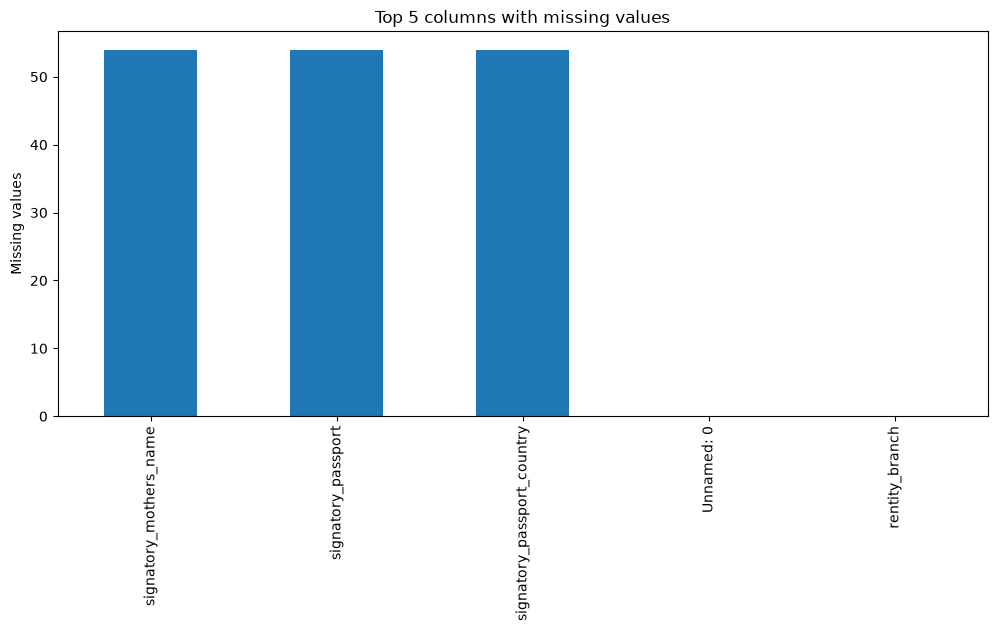

In [206]:
import matplotlib.pyplot as plt

missing.head(5).plot(kind='bar', figsize=(12,5))
plt.ylabel("Missing values")
plt.title("Top 5 columns with missing values")
plt.show()

In [207]:
df.isna().sum().sort_values(ascending=False)

signatory_mothers_name        54
signatory_passport            54
signatory_passport_country    54
Unnamed: 0                     0
rentity_branch                 0
                              ..
sender_pep_flag                0
sender_sanctions_hit           0
account_number_y               0
receiver_pep_flag              0
receiver_sanctions_hit         0
Length: 76, dtype: int64

In [208]:
df.duplicated().sum()

np.int64(0)

## Transaction Amount Analysis

In [209]:
df["tx_amount_local"].describe()

count    2.760000e+02
mean     6.303825e+06
std      3.344515e+07
min      3.115420e+03
25%      1.421498e+06
50%      1.855444e+06
75%      7.037074e+06
max      5.527964e+08
Name: tx_amount_local, dtype: float64

Text(4.444444444444445, 0.5, 'Frequency')

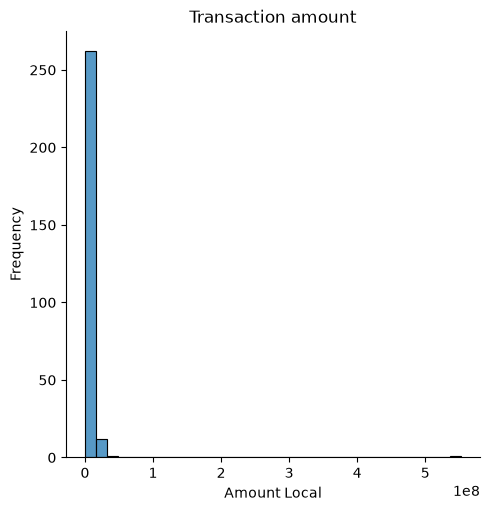

In [210]:
sns.displot(df["tx_amount_local"])
plt.title("Transaction amount")
plt.xlabel("Amount Local")
plt.ylabel("Frequency")

Text(4.444444444444445, 0.5, 'Frequency ')

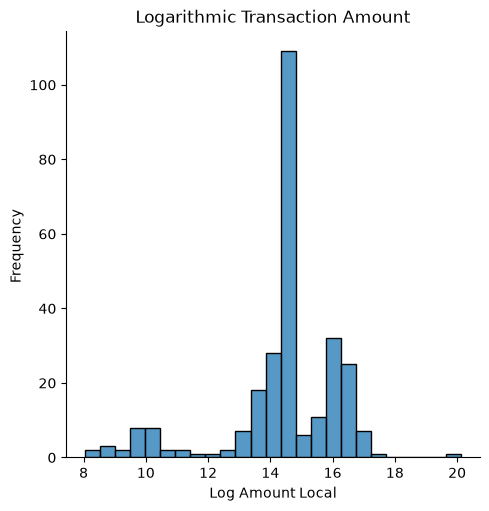

In [211]:
import numpy as np
df["log_tx_amount_local"] = np.log1p(df["tx_amount_local"])
sns.displot(df["log_tx_amount_local"])
plt.title("Logarithmic Transaction Amount")
plt.xlabel("Log Amount Local")
plt.ylabel("Frequency ")

In [212]:
df.sort_values("tx_amount_local",ascending=False)[["report_id", "tx_number", "tx_date", "tx_amount_local", "from_country", "to_country", "indicators"]].head(10)

,report_id,tx_number,tx_date,tx_amount_local,from_country,to_country,indicators
43,RPT-2026-000044,SAMLD-3267846600-37208,2022-10-08 16:12:51,5.527964e+08,GB,GB,TBML-TEC-001
92,RPT-2026-000093,SAMLD-207936746-88017,2022-10-10 12:02:08,3.311414e+07,GB,GB,OD
144,RPT-2026-000145,SAMLD-900000000026-100058,2022-11-06 19:17:46,2.202177e+07,GB,AE,OD
211,RPT-2026-000212,SAMLD-900000000086-100157,2022-11-06 13:57:25,2.144158e+07,GB,AE,OD
183,RPT-2026-000184,SAMLD-900000000063-100115,2022-11-06 05:52:21,2.131478e+07,GB,AE,OD
116,RPT-2026-000117,SAMLD-900000000002-100016,2022-11-06 17:53:24,2.107877e+07,GB,AE,OD
195,RPT-2026-000196,SAMLD-900000000075-100132,2022-11-06 19:22:42,1.969028e+07,GB,AE,OD
130,RPT-2026-000131,SAMLD-900000000013-100037,2022-11-06 21:04:35,1.949195e+07,GB,AE,OD
170,RPT-2026-000171,SAMLD-900000000050-100096,2022-11-06 01:46:43,1.929211e+07,GB,AE,OD
156,RPT-2026-000157,SAMLD-900000000039-100075,2022-11-06 10:54:40,1.800295e+07,GB,AE,OD


Text(0.5, 1.0, 'Transaction Amount Outliers')

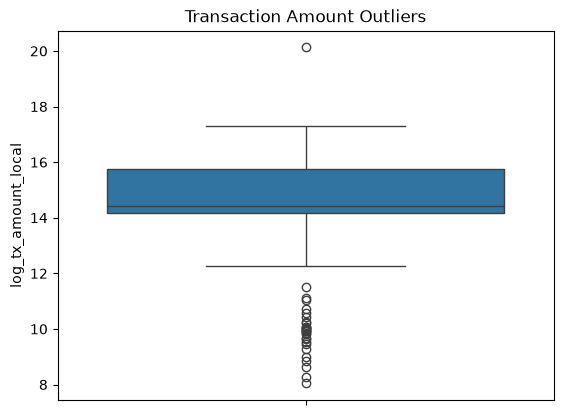

In [213]:
sns.boxplot(df["log_tx_amount_local"])
plt.title("Transaction Amount Outliers")

## Which branch submits the most STRs

In [214]:
str_report = df.sort_values("rentity_branch", ascending=False)
str_report["rentity_branch"].value_counts()

rentity_branch
BR_026    6
BR_025    6
BR_024    6
BR_023    6
BR_022    6
BR_021    6
BR_020    6
BR_019    6
BR_018    6
BR_017    6
BR_016    6
BR_015    6
BR_014    6
BR_013    6
BR_012    6
BR_011    6
BR_010    6
BR_009    6
BR_008    6
BR_007    6
BR_006    6
BR_005    6
BR_004    6
BR_003    6
BR_002    6
BR_001    6
BR_049    5
BR_048    5
BR_047    5
BR_046    5
BR_045    5
BR_044    5
BR_043    5
BR_042    5
BR_041    5
BR_040    5
BR_039    5
BR_038    5
BR_037    5
BR_036    5
BR_035    5
BR_034    5
BR_033    5
BR_032    5
BR_031    5
BR_030    5
BR_029    5
BR_028    5
BR_027    5
BR_000    5
Name: count, dtype: int64

Text(0.5, 1.0, 'Top 10 branches with most STR reports')

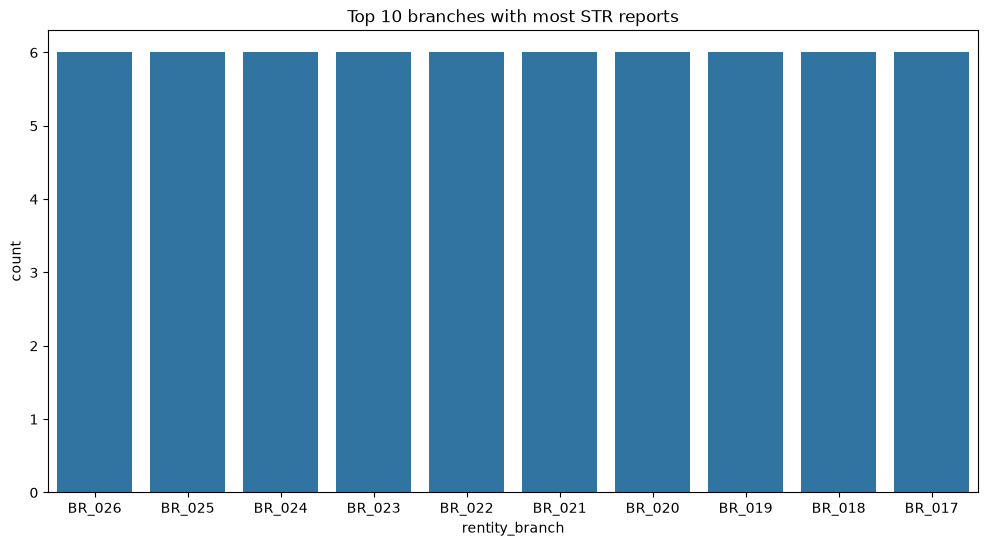

In [215]:
plt.figure(figsize=(12, 6))
sns.barplot(str_report["rentity_branch"].value_counts().head(10))
plt.title("Top 10 branches with most STR reports")

### Amount transacted by branches

In [216]:
x = df.groupby("rentity_branch")["tx_amount_local"].agg(    
    count="count",
    total="sum",
    mean="mean",
    median="median")
x.sort_values("total",ascending=False)

,count,total,mean,median
rentity_branch,,,,
BR_044,5,5.680607e+08,1.136121e+08,1841811.680
BR_017,6,4.956364e+07,8.260607e+06,7652943.445
BR_043,5,4.892970e+07,9.785940e+06,1828479.390
BR_021,6,4.439881e+07,7.399801e+06,4831693.280
BR_034,5,4.019124e+07,8.038248e+06,2007006.210
BR_012,6,4.006227e+07,6.677045e+06,1864845.510
BR_013,6,3.348771e+07,5.581285e+06,1834574.860
BR_014,6,3.241413e+07,5.402355e+06,1990724.905
BR_023,6,3.226756e+07,5.377927e+06,1945029.475


### Country : Sender country and reciever country

from_country
GB    269
JP      2
AL      1
IT      1
CH      1
DE      1
TR      1
Name: count, dtype: int64


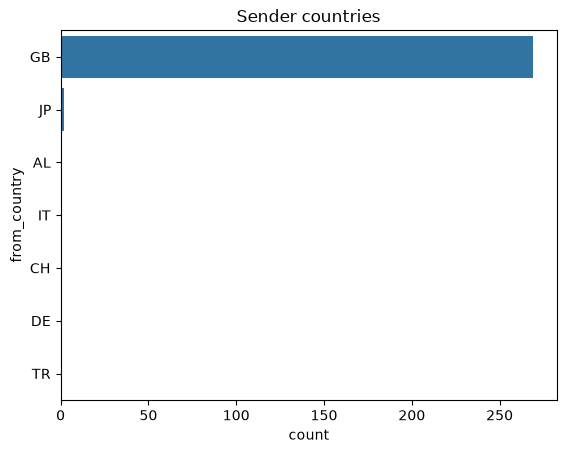

In [217]:
sns.countplot(df["from_country"])
plt.title("Sender countries")
print(df["from_country"].value_counts())

to_country
GB    228
AE     16
AL      6
IN      5
NG      5
MX      4
US      4
TR      3
IT      2
JP      1
ES      1
CH      1
Name: count, dtype: int64


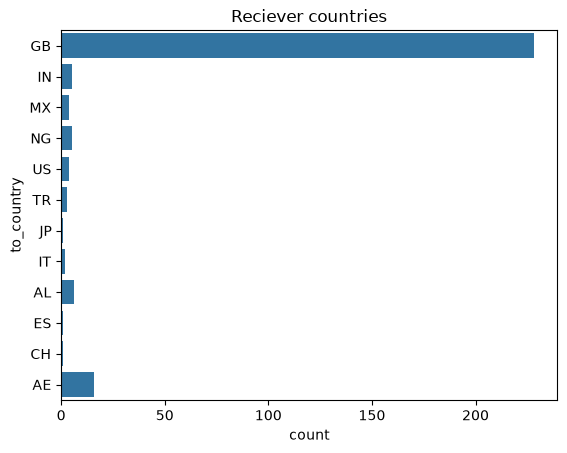

In [218]:
sns.countplot(df["to_country"])
plt.title("Reciever countries")
print(df["to_country"].value_counts())

### Coutnry to country transfer

to_country    AE  AL  CH  ES   GB  IN  IT  JP  MX  NG  TR  US
from_country                                                 
AL             0   0   0   0    1   0   0   0   0   0   0   0
CH             0   0   0   0    1   0   0   0   0   0   0   0
DE             0   0   0   0    1   0   0   0   0   0   0   0
GB            16   5   1   1  222   5   2   1   4   5   3   4
IT             0   0   0   0    1   0   0   0   0   0   0   0
JP             0   0   0   0    2   0   0   0   0   0   0   0
TR             0   1   0   0    0   0   0   0   0   0   0   0


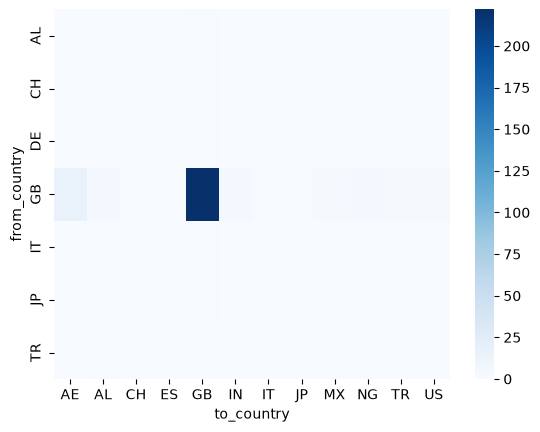

In [219]:
heat_map_country = pd.crosstab(df["from_country"],df["to_country"])
sns.heatmap(heat_map_country, cmap="Blues")
print(heat_map_country)

### Transmode Code

tx_transmode_code
Z    100
F     49
A     40
P     39
E     33
J     15
Name: count, dtype: int64


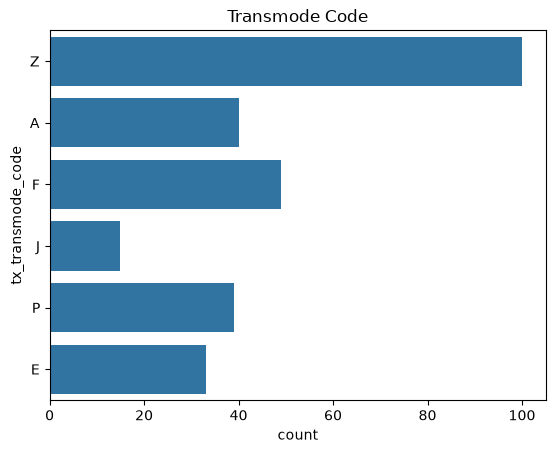

In [220]:
sns.countplot(df["tx_transmode_code"])
plt.title("Transmode Code")
print(df["tx_transmode_code"].value_counts())


In [221]:
transmode_code_transactions = df.groupby("tx_transmode_code")["tx_amount_local"].agg(['count', 'mean', 'median', 'sum'])
transmode_code_transactions

,count,mean,median,sum
tx_transmode_code,,,,
A,40,3.896512e+06,1843359.20,1.558605e+08
E,33,5.941057e+06,1995173.11,1.960549e+08
F,49,3.802266e+06,1808294.85,1.863110e+08
J,15,3.851666e+07,1594612.16,5.777498e+08
P,39,5.400607e+06,1922498.46,2.106237e+08
Z,100,4.132557e+06,1863199.28,4.132557e+08


Text(0.5, 1.0, 'Mean transaction amount for each mode')

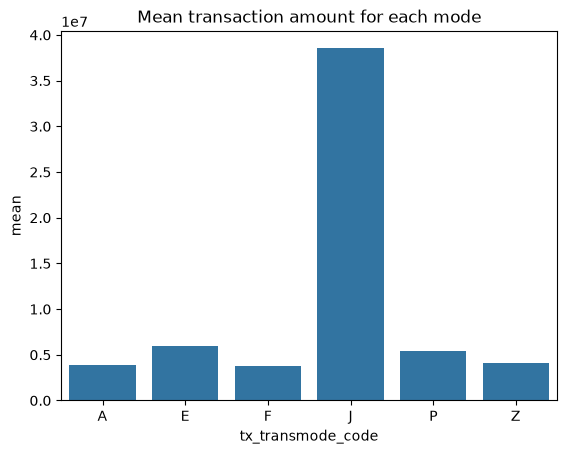

In [222]:
sns.barplot(transmode_code_transactions["mean"])
plt.title("Mean transaction amount for each mode")

# Funds Code

from_funds_code
D    103
Z    100
K     40
P     33
Name: count, dtype: int64

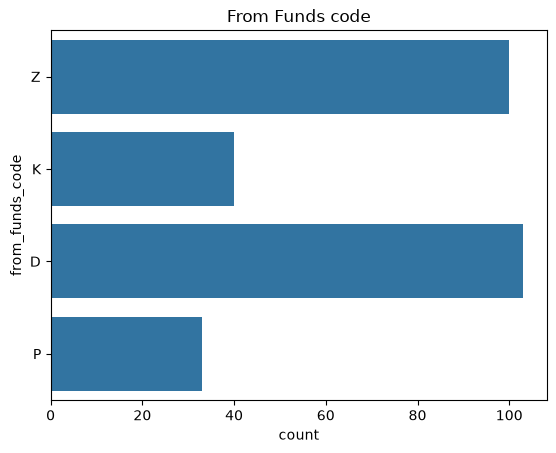

In [223]:
sns.countplot(df["from_funds_code"])
plt.title("From Funds code")
df["from_funds_code"].value_counts()

to_funds_code
D    103
Z    100
K     40
P     33
Name: count, dtype: int64

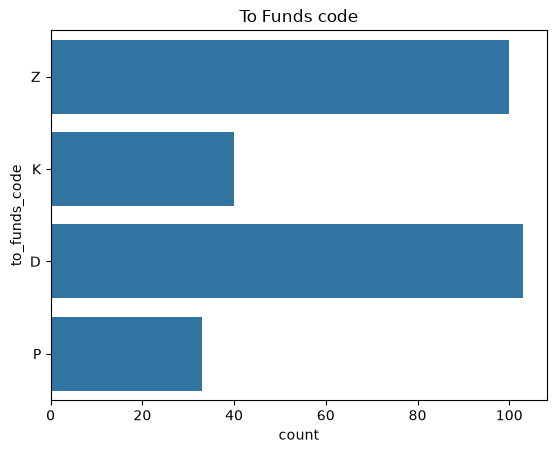

In [224]:
sns.countplot(df["to_funds_code"])
plt.title("To Funds code")
df["to_funds_code"].value_counts()

to_funds_code      D   K   P    Z
from_funds_code                  
D                103   0   0    0
K                  0  40   0    0
P                  0   0  33    0
Z                  0   0   0  100


<Axes: xlabel='to_funds_code', ylabel='from_funds_code'>

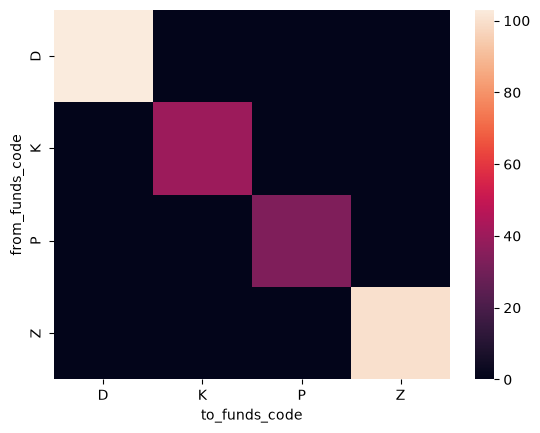

In [225]:
funds_code_map = pd.crosstab(df["from_funds_code"],df["to_funds_code"])
print(funds_code_map)
sns.heatmap(funds_code_map)

In [226]:
df.groupby('from_funds_code')['tx_amount_local'].agg(['count', 'mean', 'median', 'sum'])

,count,mean,median,sum
from_funds_code,,,,
D,103,9.462957e+06,1832748.69,9.746846e+08
K,40,3.896512e+06,1843359.20,1.558605e+08
P,33,5.941057e+06,1995173.11,1.960549e+08
Z,100,4.132557e+06,1863199.28,4.132557e+08


### Date and time analysis

In [227]:
df['tx_date']
date_time = pd.to_datetime(df["tx_date"])
df['tx_year'] = date_time.dt.year
df['tx_month'] = date_time.dt.month
df['tx_day'] = date_time.dt.day
df['tx_dayofweek'] = date_time.dt.dayofweek
df['is_weekend'] = df['tx_dayofweek'].isin([5,6]).astype(int)


In [228]:
df.groupby("tx_month")["tx_amount_local"].agg(['count', 'sum', 'mean', 'median'])

,count,sum,mean,median
tx_month,,,,
10,105,7.106056e+08,6.767672e+06,871538.53
11,171,1.029250e+09,6.019006e+06,1935147.99


In [229]:
df.groupby("tx_year")["tx_amount_local"].agg(['count', 'sum', 'mean', 'median'])

,count,sum,mean,median
tx_year,,,,
2022,276,1.739856e+09,6.303825e+06,1855444.22


### Report submission analysis
#### are transaction greater than 1M reported on time?

In [230]:
df.loc[:,["tx_date","submission_date"]]

,tx_date,submission_date
0,2022-10-07 10:46:37,2026-06-14 15:42:08
1,2022-10-07 11:19:32,2026-06-14 15:42:08
2,2022-10-07 11:35:42,2026-06-14 15:42:08
3,2022-10-07 11:45:53,2026-06-14 15:42:08
4,2022-10-07 12:39:03,2026-06-14 15:42:08
...,...,...
271,2022-11-04 06:56:32,2026-06-14 15:42:08
272,2022-11-01 11:48:06,2026-06-14 15:42:08
273,2022-11-02 12:25:23,2026-06-14 15:42:08
274,2022-11-03 18:31:07,2026-06-14 15:42:08


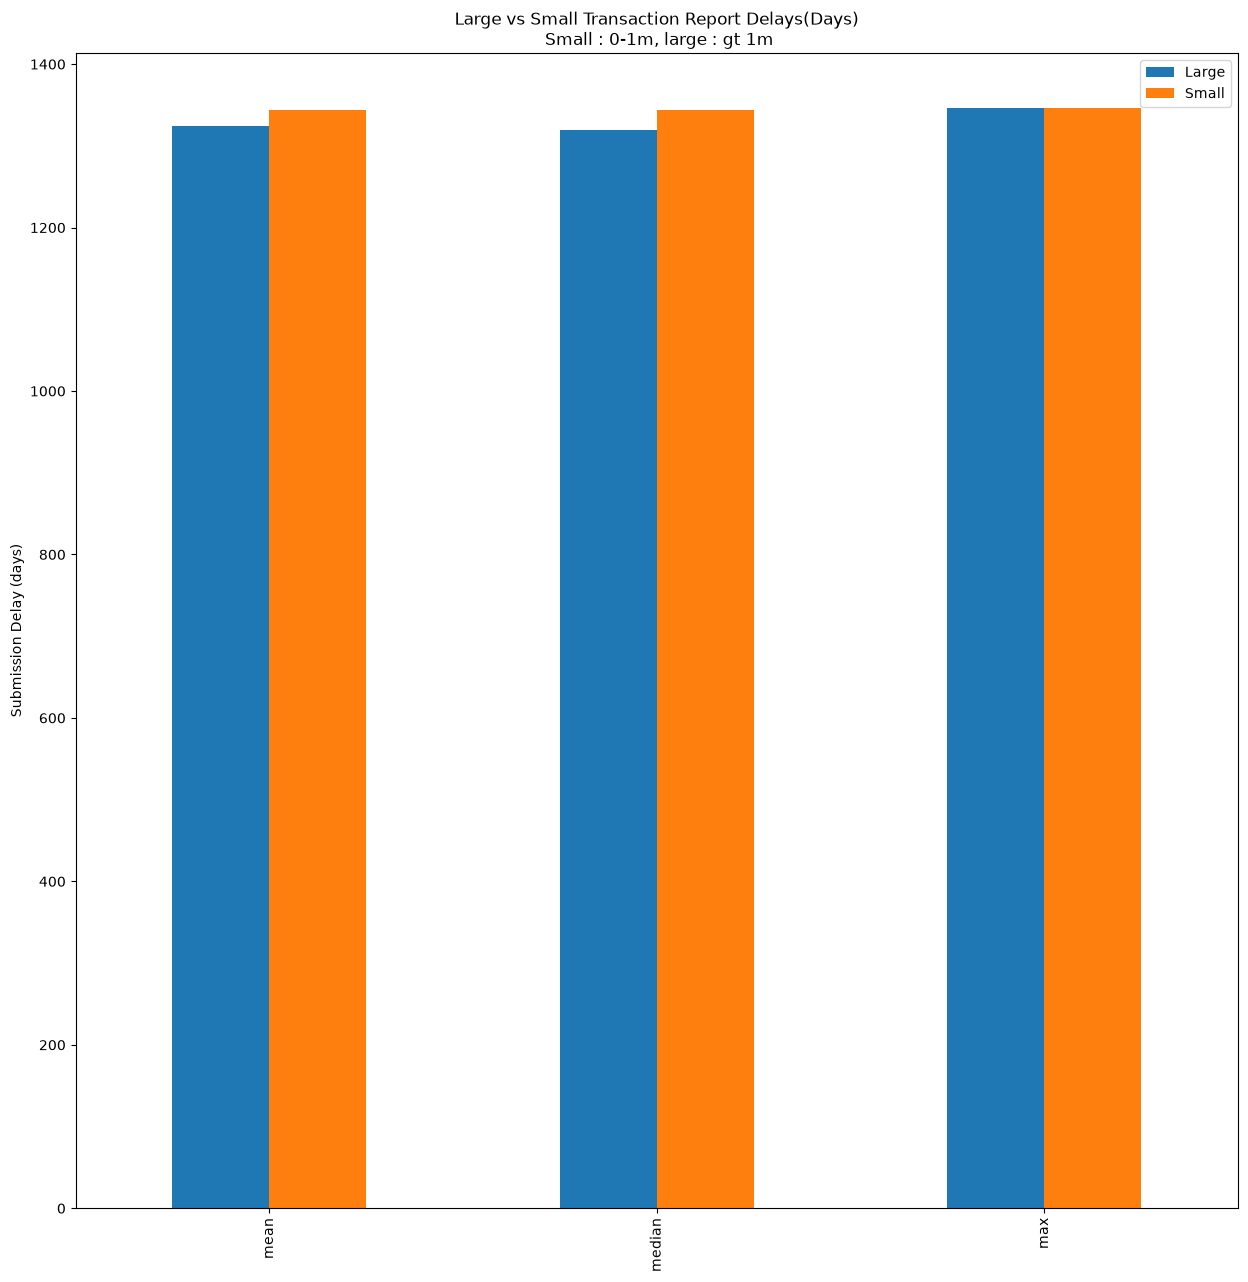

In [231]:
import pandas as pd

# Convert to datetime
s_time = pd.to_datetime(df["submission_date"])
date_time = pd.to_datetime(df["tx_date"])


df["tx_year"] = date_time.dt.year
df["tx_month"] = date_time.dt.month
df["tx_day"] = date_time.dt.day
df["tx_dayofweek"] = date_time.dt.dayofweek
df["is_weekend"] = df["tx_dayofweek"].isin([5, 6]).astype(int)


df["submission_delay_days"] = (s_time - date_time).dt.days


large_value = df[df["tx_amount_local"] > 1.0e6]
small_value = df[(df["tx_amount_local"] > 1.0e5) & (df["tx_amount_local"] < 1.0e6)]

l = large_value["submission_delay_days"].agg(["mean", "median", "max"])
s = small_value["submission_delay_days"].agg(["mean", "median", "max"])
stats = pd.DataFrame({
    "Large": l,
    "Small": s
})



stats.plot(kind="bar",figsize=(15,15))
plt.ylabel("Submission Delay (days)")
plt.title("Large vs Small Transaction Report Delays(Days)\n Small : 0-1m, large : gt 1m" )
plt.legend
plt.show()

### Types of account involved

from_account_type
Z    97
D    54
C    46
B    44
A    35
Name: count, dtype: int64


<Axes: xlabel='count', ylabel='from_account_type'>

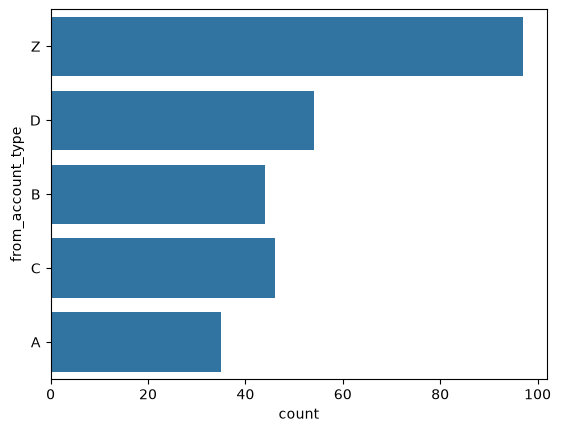

In [232]:
print(df['from_account_type'].value_counts())
sns.countplot(df['from_account_type'])

In [233]:
df.groupby('from_account_type')['tx_amount_local'].agg(['count', 'mean', 'median', 'sum'])

,count,mean,median,sum
from_account_type,,,,
A,35,3.055776e+06,1825859.410,1.069522e+08
B,44,4.156449e+06,1877453.915,1.828838e+08
C,46,5.693336e+06,1930079.745,2.618935e+08
D,54,5.089103e+06,1819717.675,2.748115e+08
Z,97,9.415615e+06,1877588.610,9.133147e+08


### Instance of accounts less than 90 days involved

In [234]:
o_time = pd.to_datetime(df["from_account_opened"])
date_time = pd.to_datetime(df["tx_date"])

df['account_age_days'] = (o_time - date_time).dt.days
df['new_account_90days'] = df['account_age_days'] <= 90

df.groupby('new_account_90days')['tx_amount_local'].agg(['count', 'mean', 'median', 'sum'])



,count,mean,median,sum
new_account_90days,,,,
False,222,6.911364e+06,1851341.505,1.534323e+09
True,54,3.806163e+06,1870386.750,2.055328e+08


### Reasons

In [235]:
df["reason"].head(20)

0                      Suspicious transaction observed.
1     During the branch's periodic transaction-monit...
2     During the branch's periodic transaction-monit...
3     During the branch's periodic transaction-monit...
4                      Suspicious transaction observed.
5     During the branch's periodic transaction-monit...
6     During the branch's periodic transaction-monit...
7     During the branch's periodic transaction-monit...
8                      Suspicious transaction observed.
9     During the branch's periodic transaction-monit...
10                     Suspicious transaction observed.
11    During the branch's periodic transaction-monit...
12                     Suspicious transaction observed.
13    During the branch's periodic transaction-monit...
14    During the branch's periodic transaction-monit...
15    During the branch's periodic transaction-monit...
16    During the branch's periodic transaction-monit...
17    During the branch's periodic transaction-m

In [236]:
df["comments"]

0      Report filed by reporting entity.
1      Report filed by reporting entity.
2      Report filed by reporting entity.
3      Report filed by reporting entity.
4      Report filed by reporting entity.
                     ...                
271    Report filed by reporting entity.
272    Report filed by reporting entity.
273    Report filed by reporting entity.
274    Report filed by reporting entity.
275    Report filed by reporting entity.
Name: comments, Length: 276, dtype: str

In [237]:
df.groupby(pd.cut(df['reason_word_count'], bins=5))['tx_amount_local'].agg(['count', 'mean', 'median'])

,count,mean,median
reason_word_count,,,
"(2.813, 40.4]",100,4.132557e+06,1863199.280
"(152.6, 190.0]",176,7.537500e+06,1854754.265


### reporter analysis

reporter_gender
M    276
Name: count, dtype: int64


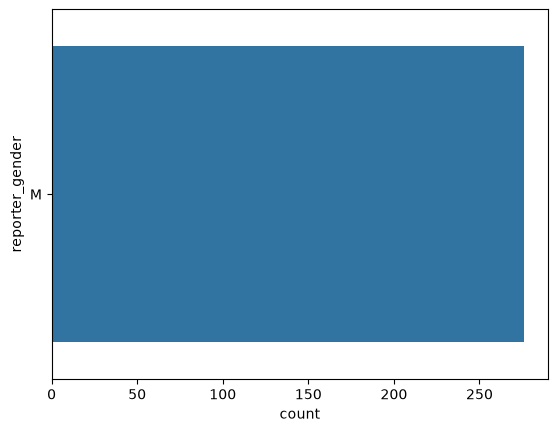

In [238]:
sns.countplot(df['reporter_gender'])
print(df["reporter_gender"].value_counts())


reporter_occupation
Compliance Officer    276
Name: count, dtype: int64


<Axes: xlabel='count', ylabel='reporter_occupation'>

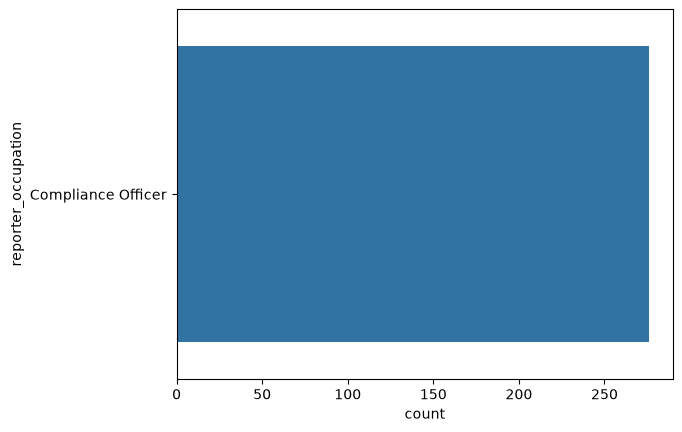

In [239]:
print(df['reporter_occupation'].value_counts())
sns.countplot(df['reporter_occupation'])

## High amount and cross border (More than 1 Million)

In [240]:
x = df[(df["tx_amount_local"]>1_000_000) & (df["from_country"] != df["to_country"])]
x.shape
x.loc[:,["tx_amount_local","from_country","to_country"]]


,tx_amount_local,from_country,to_country
2,1214019.81,GB,MX
10,1257060.30,GB,NG
13,2087372.18,GB,TR
34,2109366.45,GB,TR
40,1234763.73,GB,AL
56,1116597.24,GB,AL
62,1592555.66,GB,MX
75,1198267.02,GB,AL
78,4237143.02,GB,MX
81,1196039.84,GB,AL


##### transaction from GB to AE needs proper tracking

## New account and large value transaction

In [241]:
df[(df['new_account_90days'] == True) & (df['tx_amount_local'] > 1_000_000)][
    ['report_id', 'tx_amount_local', 'from_account_type', 'indicators',"from_country","to_country"]
].head()

,report_id,tx_amount_local,from_account_type,indicators,from_country,to_country
7,RPT-2026-000008,2845747.68,Z,OD,GB,GB
18,RPT-2026-000019,1618911.76,D,OD,GB,GB
31,RPT-2026-000032,1436086.85,Z,OD,GB,GB
34,RPT-2026-000035,2109366.45,Z,OD,GB,TR
44,RPT-2026-000045,1190538.70,D,OD,GB,GB


## pep_flags_check

In [242]:
sender_pep = df[df["sender_pep_flag"]==1]
sender_pep[["from_country","sender_account","sender_pep_flag","tx_amount_local"]]

,from_country,sender_account,sender_pep_flag,tx_amount_local
9,GB,NP00000000000099211090,1,2161766.07
15,GB,NP00000000002752249116,1,1628443.64
16,GB,NP00000000000272217664,1,5212784.37
24,GB,NP00000000003015575507,1,1040541.70
35,GB,NP00000000001340831574,1,4732194.04
40,GB,NP00000000001897370084,1,1234763.73
53,GB,NP00000000000099211090,1,1709591.07
67,GB,NP00000000003875786430,1,770763.86
75,GB,NP00000000001273894252,1,1198267.02
103,GB,NP00000000000099211090,1,3607611.01


from_country
GB    23
Name: count, dtype: int64


Text(0.5, 1.0, 'Sender country with pep_flags')

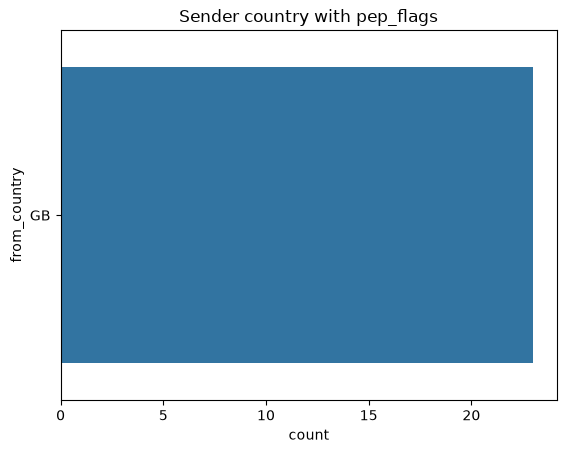

In [243]:
print(sender_pep["from_country"].value_counts())
sns.countplot(sender_pep["from_country"])
plt.title("Sender country with pep_flags")

to_country
GB    20
AL     2
AE     1
Name: count, dtype: int64


Text(0.5, 1.0, 'reciever countries with pep flags')

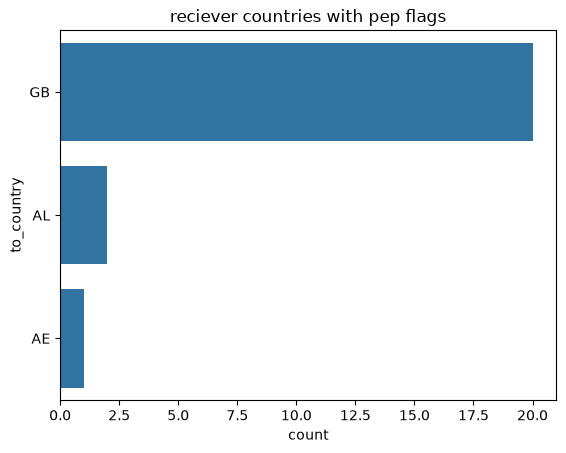

In [246]:
print(sender_pep["to_country"].value_counts())
sns.countplot(sender_pep["to_country"])
plt.title("reciever countries with pep flags")

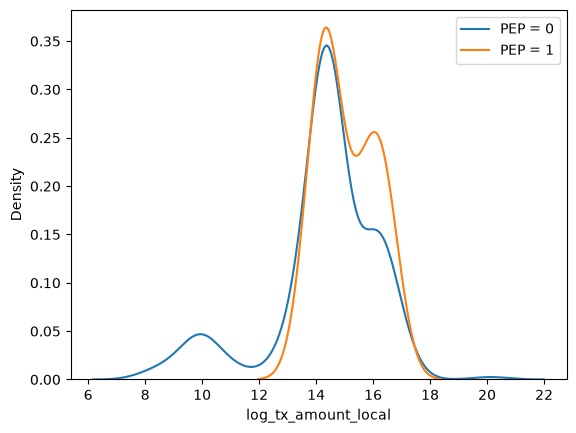

In [264]:
sns.kdeplot(
    data=df[df["sender_pep_flag"] == 0],
    x="log_tx_amount_local",
    label="PEP = 0"
)

sns.kdeplot(
    data=df[df["sender_pep_flag"] == 1],
    x="log_tx_amount_local",
    label="PEP = 1"
)

plt.legend()

## Sanctions

from_country
GB    6
JP    1
Name: count, dtype: int64


Text(0.5, 1.0, 'Sender country with sanctions_flags')

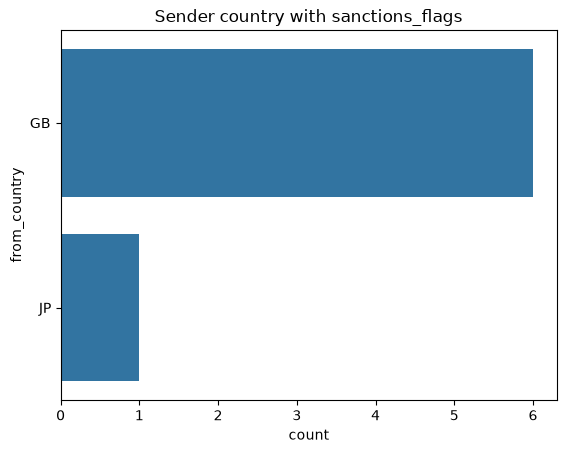

In [252]:
sender_sanctions = df[df["sender_sanctions_hit"]==1]
sender_sanctions[["from_country","sender_account","sender_pep_flag","tx_amount_local"]]
print(sender_sanctions["from_country"].value_counts())
sns.countplot(sender_sanctions["from_country"])
plt.title("Sender country with sanctions_flags")

to_country
GB    7
Name: count, dtype: int64


Text(0.5, 1.0, 'Receiver country with sanctions_flags')

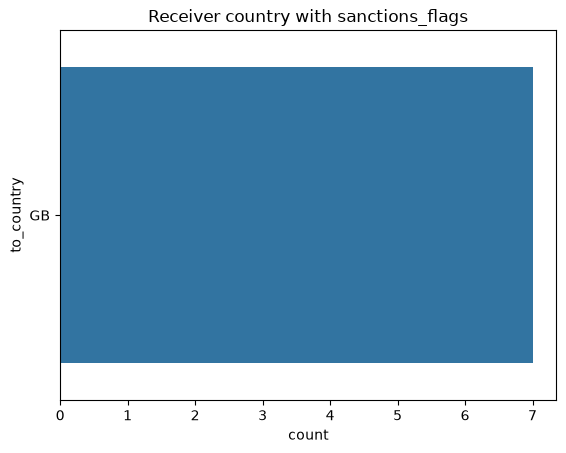

In [251]:
sender_sanctions = df[df["sender_sanctions_hit"]==1]
sender_sanctions[["from_country","sender_account","sender_pep_flag","tx_amount_local"]]
print(sender_sanctions["to_country"].value_counts())
sns.countplot(sender_sanctions["to_country"])
plt.title("Receiver country with sanctions_flags")

### Pep_flag is 1 and cross border transactions

In [254]:
high_risk = df[(df["from_country"]!=df["to_country"]) & (df["sender_pep_flag"]==1)]
high_risk

,Unnamed: 0,report_id,entity_reference,rentity_id,rentity_branch,report_code,submission_code,submission_date,currency_local,reason,...,receiver_sanctions_hit,log_tx_amount_local,tx_year,tx_month,tx_day,tx_dayofweek,is_weekend,submission_delay_days,account_age_days,new_account_90days
40,40,RPT-2026-000041,NIMB-2026-000041,1001,BR_041,STR,E,2026-06-14 15:42:08,NPR,During the branch's periodic transaction-monit...,...,1,14.026391,2022,10,8,5,1,1345,442,False
75,75,RPT-2026-000076,PRABHU-2026-000076,1016,BR_026,STR,E,2026-06-14 15:42:08,NPR,During the branch's periodic transaction-monit...,...,1,13.996388,2022,10,9,6,1,1343,608,False
130,130,RPT-2026-000131,ADBL-2026-000131,1011,BR_031,STR,E,2026-06-14 15:42:08,NPR,Suspicious transaction observed.,...,1,16.785512,2022,11,6,6,1,1315,822,False
